In [1]:
# To run this notebook, run pip install -r requirements.txt (ideally in a virtual environment)
# and run it in a directory with the /Data and /images folders with the relevant files
# taken directly from the .pkg file provided. 

## Setup

First we load the data, explore its basic structure and parse out the entity classes from the specific entities to facilitate downstream analysis. 

In [2]:
# Import libraries

import pandas as pd
from owlready2 import *
from pyvis.network import Network
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')

# Load the Oregano Knowledge Graph data and create useful headers
oregano = pd.read_csv('Data/OREGANO_V2.1.tsv', sep='\t', header=None, names=['subject', 'relation', 'object'])

# Preview the data
oregano

,subject,relation,object
0,COMPOUND:1,has_code,B01AE02
1,COMPOUND:2,has_code,L01FE01
2,COMPOUND:3,has_code,R05CB13
3,COMPOUND:4,has_code,L01XX29
4,COMPOUND:5,has_code,L04AB01
...,...,...,...
823000,PROTEIN:22090,gene_product_of,GENE:32165
823001,PROTEIN:22091,gene_product_of,GENE:33606
823002,PROTEIN:22093,gene_product_of,GENE:35418
823003,PROTEIN:22095,gene_product_of,GENE:31330


In [3]:
oregano.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 823005 entries, 0 to 823004
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   subject   823005 non-null  object
 1   relation  823005 non-null  object
 2   object    823005 non-null  object
dtypes: object(3)
memory usage: 18.8+ MB


In [4]:
# Parse the subject and object columns to separate the class and id using ':' as the separator and convert ids to integers
oregano_expanded = oregano.copy()

oregano_expanded['subject_class'] = oregano['subject'].str.split(':').str[0]
oregano_expanded['subject_id'] = oregano['subject'].str.split(':').str[1]
oregano_expanded['object_class'] = oregano['object'].str.split(':').str[0]
oregano_expanded['object_id'] = oregano['object'].str.split(':').str[1]

oregano_expanded

,subject,relation,object,subject_class,subject_id,object_class,object_id
0,COMPOUND:1,has_code,B01AE02,COMPOUND,1,B01AE02,NaN
1,COMPOUND:2,has_code,L01FE01,COMPOUND,2,L01FE01,NaN
2,COMPOUND:3,has_code,R05CB13,COMPOUND,3,R05CB13,NaN
3,COMPOUND:4,has_code,L01XX29,COMPOUND,4,L01XX29,NaN
4,COMPOUND:5,has_code,L04AB01,COMPOUND,5,L04AB01,NaN
...,...,...,...,...,...,...,...
823000,PROTEIN:22090,gene_product_of,GENE:32165,PROTEIN,22090,GENE,32165
823001,PROTEIN:22091,gene_product_of,GENE:33606,PROTEIN,22091,GENE,33606
823002,PROTEIN:22093,gene_product_of,GENE:35418,PROTEIN,22093,GENE,35418
823003,PROTEIN:22095,gene_product_of,GENE:31330,PROTEIN,22095,GENE,31330


In [5]:
# Exclude the records with 'has_code' relation as each object (code) is a 'literal', it is not an entity like the other objects (activity, effect, etc.)
oregano_core = oregano_expanded[oregano_expanded['relation'] != 'has_code']

# Display the number of records for each unique combination of subject_class, object_class and relation
snapshot = pd.DataFrame(oregano_core[['subject_class', 'object_class', 'relation']].value_counts().sort_values(ascending=False).sort_index()).reset_index()
snapshot

,subject_class,object_class,relation,count
0,COMPOUND,ACTIVITY,decrease_activity,3331
1,COMPOUND,ACTIVITY,has_activity,12584
2,COMPOUND,ACTIVITY,increase_activity,10518
3,COMPOUND,COMPOUND,decrease_efficacy,215222
4,COMPOUND,COMPOUND,increase_efficacy,44114
5,COMPOUND,DISEASE,is_substance_that_treats,1394
6,COMPOUND,EFFECT,decrease_effect,255
7,COMPOUND,EFFECT,has_effect,19160
8,COMPOUND,EFFECT,increase_effect,18999
9,COMPOUND,GENE,is_affecting,8905


## Statistical Overview of the Graph

### 1. Relations

Relations in the graph, also known as edges, links or predicates, describe how different entities relate to each other. For example there is a relation called `has_effect` that connects `compounds` (the subject) to `effects` (the object).

In total there are 18 types of relations.

In [6]:
# Print the types of relations and number of them
relation_types = oregano['relation'].unique()

print(f'Types of relations: {relation_types}\n')
print(f'There are {len(relation_types)} types of relations in total.')

Types of relations: ['has_code' 'has_target' 'increase_activity' 'has_activity'
 'decrease_activity' 'increase_effect' 'has_effect' 'decrease_effect'
 'increase_efficacy' 'decrease_efficacy' 'causes_condition'
 'has_phenotype' 'is_affecting' 'is_substance_that_treats' 'acts_within'
 'has_indication' 'has_side_effect' 'gene_product_of']

There are 18 types of relations in total.


In [7]:
# Count the number of relations in the graph for each type
relation_counts = oregano.groupby('relation').size().sort_values(ascending=False)

relation_counts


relation
decrease_efficacy           215222
has_target                  202539
has_side_effect             112532
has_phenotype                88791
acts_within                  44865
increase_efficacy            44114
has_effect                   19160
increase_effect              18999
causes_condition             17287
has_activity                 12584
gene_product_of              10881
increase_activity            10518
is_affecting                  8905
has_indication                8225
has_code                      3403
decrease_activity             3331
is_substance_that_treats      1394
decrease_effect                255
dtype: int64

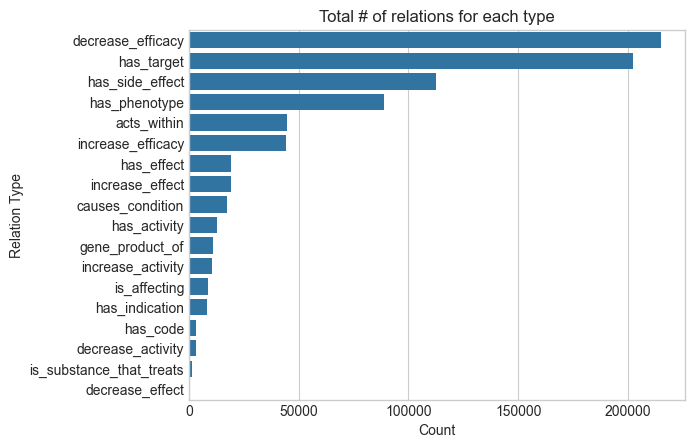

In [8]:
# Plot the number of relations for each type to get a sense of scale

sns.barplot(y=relation_counts.index, x=relation_counts.values, orient='h')
plt.title('Total # of relations for each type')
plt.xlabel('Count')
plt.ylabel('Relation Type');

## 2. Nodes

Nodes in a graph are either the subject or the object; the things that are connected together by the edges. 

There are 11 types of nodes.

In [9]:
# Note: using the version of the Oregano dataframe that excludes the 'has_code' relation
subjects = pd.Series(oregano_core['subject_class'].unique())
objects = pd.Series(oregano_core['object_class'].unique())

# Merge the two series and organise alphabetically
nodes = pd.concat([subjects, objects]).unique()
nodes = pd.Series(nodes).sort_values().reset_index(drop=True)
nodes

print(nodes)
print(f'\nThere are {len(nodes)} nodes in total.')

# Note all subjects are also objects in this case, so the combination of subjects and objects is equivalent to the list of objects

0        ACTIVITY
1        COMPOUND
2         DISEASE
3          EFFECT
4            GENE
5      INDICATION
6        MOLECULE
7         PATHWAY
8       PHENOTYPE
9         PROTEIN
10    SIDE_EFFECT
dtype: object

There are 11 nodes in total.


## 3. Links between Nodes and Relations

By looking at the number of relations in each subject class and object class we can quickly identify which entities are related to each other in which ways. For example, we can see that there are 44,865 links between `Gene` and `Pathway` through the `acts_within` relation. This information allows us to define the direction of each relation and the types of connections between each relation in the ontology.

In [10]:
# Show the number of links between subjects and relations 

subject_and_relations_crosstab = pd.crosstab(oregano_core['relation'], oregano_core['subject_class'], margins=True)
subject_and_relations_crosstab 

subject_class,COMPOUND,DISEASE,GENE,PROTEIN,All
relation,,,,,
acts_within,0,0,44865,0,44865
causes_condition,0,0,17287,0,17287
decrease_activity,3331,0,0,0,3331
decrease_effect,255,0,0,0,255
decrease_efficacy,215222,0,0,0,215222
gene_product_of,0,0,0,10881,10881
has_activity,12584,0,0,0,12584
has_effect,19160,0,0,0,19160
has_indication,8225,0,0,0,8225


In [11]:
# Show the number of links between objects and relations 

object_and_relations_crosstab = pd.crosstab(oregano_core['relation'], oregano_core['object_class'], margins=True)
object_and_relations_crosstab

object_class,ACTIVITY,COMPOUND,DISEASE,EFFECT,GENE,INDICATION,MOLECULE,PATHWAY,PHENOTYPE,PROTEIN,SIDE_EFFECT,All
relation,,,,,,,,,,,,
acts_within,0,0,0,0,0,0,0,44865,0,0,0,44865
causes_condition,0,0,17287,0,0,0,0,0,0,0,0,17287
decrease_activity,3331,0,0,0,0,0,0,0,0,0,0,3331
decrease_effect,0,0,0,255,0,0,0,0,0,0,0,255
decrease_efficacy,0,215222,0,0,0,0,0,0,0,0,0,215222
gene_product_of,0,0,0,0,10881,0,0,0,0,0,0,10881
has_activity,12584,0,0,0,0,0,0,0,0,0,0,12584
has_effect,0,0,0,19160,0,0,0,0,0,0,0,19160
has_indication,0,0,0,0,0,8225,0,0,0,0,0,8225


## 4. Ontology

We visualise the ontology in `pyvis` by looping through the initial `snapshot` of the data we took which captured the full set of unique nodes (subject and object classes) and the relations connecting them.<sup>1</sup>

In [12]:
# Turn the snapshot drataframe of all unique combinations of subject_class, object_class and relation into a list of lists for easier processing
ontology_list = []
for index, row in snapshot.iterrows():
    ontology_list.append([row['subject_class'], row['relation'], row['object_class']]) 

ontology_list

[['COMPOUND', 'decrease_activity', 'ACTIVITY'],
 ['COMPOUND', 'has_activity', 'ACTIVITY'],
 ['COMPOUND', 'increase_activity', 'ACTIVITY'],
 ['COMPOUND', 'decrease_efficacy', 'COMPOUND'],
 ['COMPOUND', 'increase_efficacy', 'COMPOUND'],
 ['COMPOUND', 'is_substance_that_treats', 'DISEASE'],
 ['COMPOUND', 'decrease_effect', 'EFFECT'],
 ['COMPOUND', 'has_effect', 'EFFECT'],
 ['COMPOUND', 'increase_effect', 'EFFECT'],
 ['COMPOUND', 'is_affecting', 'GENE'],
 ['COMPOUND', 'has_indication', 'INDICATION'],
 ['COMPOUND', 'has_target', 'MOLECULE'],
 ['COMPOUND', 'has_target', 'PROTEIN'],
 ['COMPOUND', 'has_side_effect', 'SIDE_EFFECT'],
 ['DISEASE', 'has_phenotype', 'PHENOTYPE'],
 ['GENE', 'causes_condition', 'DISEASE'],
 ['GENE', 'acts_within', 'PATHWAY'],
 ['PROTEIN', 'gene_product_of', 'GENE']]

In [13]:
# Initalise the network graph with force direction to allow multiple edges between the same nodes
net = Network(height='750px', width='100%', directed=True)

# Iterate through the nodes and add them to the network
for n in nodes:
    net.add_node(n_id = n, title = n)

# Iterate through the rows in the snapshot dataframe and add the edges to the network
for item in ontology_list:
        if item[0] == 'COMPOUND' and item[2] == 'COMPOUND':
             net.add_edge(item[0], item[2], label='increases_/decreases_efficacy')
        else:
            net.add_edge(item[0], item[2], label=item[1])


# Enable some physics, interactivity for better visualisation of multiple edges between the same nodes (through dynamic edges)
net.toggle_physics(True)
net.repulsion()
net.show_buttons(filter_=['physics'])
net.set_edge_smooth('dynamic')
net.save_graph("oregano_ontology.html")

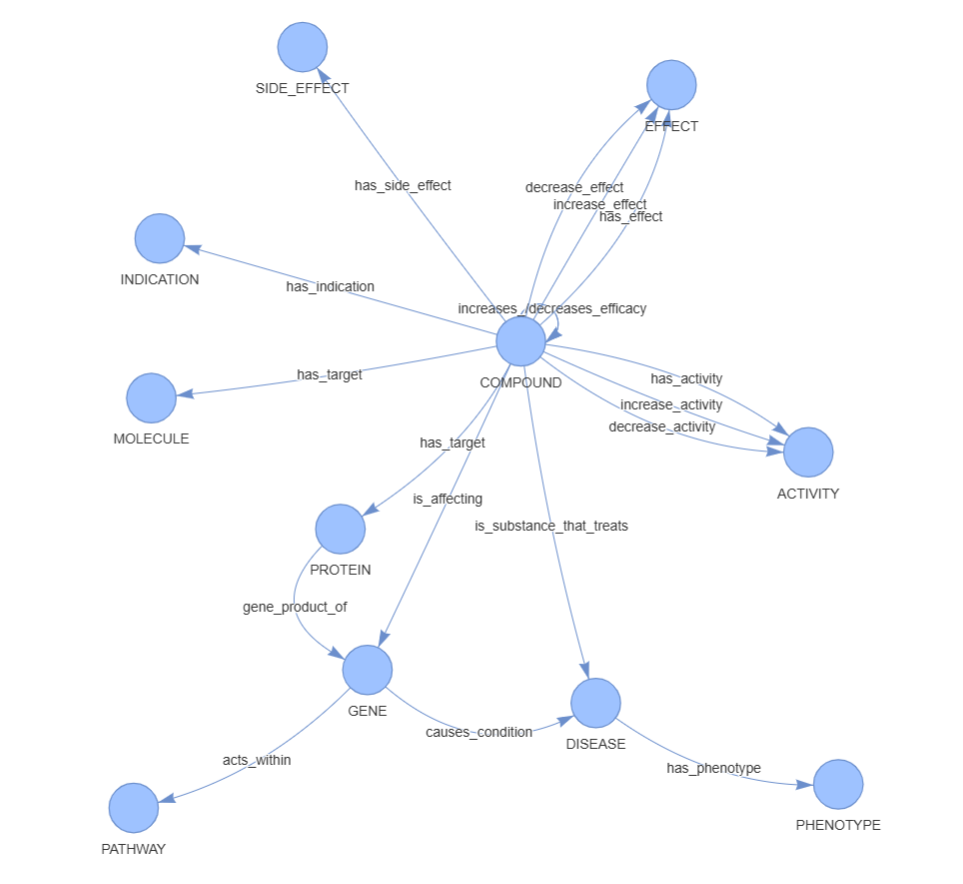

In [14]:
# Display screenshot of the network
from IPython.display import Image, display
display(Image('images/ontology_screenshot.png', width=500, height=400))

# Note: pyvis is unable to show multiple self-referencing loops on a single node
# so the 'increase_efficacy' and 'decrease_efficacy' relations for the 'COMPOUND' node have been combined into one edge for visualisation purposes.

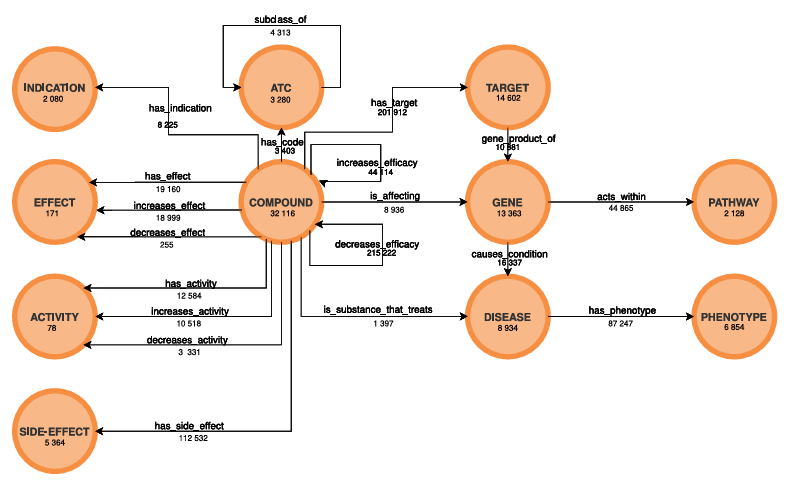

In [15]:
# Display the original version from the paper for comparison
from IPython.display import Image, display
display(Image('images/original_paper.png', width=500, height=400))

## 5. First-Order Logic in the Ontology


### Predicates

The `relation` column in the knowledge graph triples is also often also called the `predicate`. It maps onto the predicates in first order logic almost 1:1, they just require the addition of x and y variables to generalise them.

From `relation` = `has_activity` to `has_activity(x,y)`. 

### Domain

To assess whether the predicates are valid or not, we need to define which values the variables can take. 

In first-order logic this is known as the *domain* of the variables. In the language of ontologies like the Web Ontology Language (OWL) the subject has a *domain* while the object has a *range*. In all cases they define the range of valid values for that variable / entity. 

From the ontology we can identify the following predicates, domains and ranges with the ∀ (for all) quantifier.

Complete Predicate Statement | Domain | Range
|--------|---|---
∀x,∀y(increase_efficacy(x,y)) ⇒ (Compound(x) ∧ Compound(y)) | Compound | Compound
∀x,∀y(decrease_efficacy(x,y)) ⇒ (Compound(x) ∧ Compound(y)) | Compound | Compound
∀x,∀y(has_activity(x,y)) ⇒ (Compound(x) ∧ Activity(y)) | Compound | Activity
∀x,∀y(decrease_activity(x,y)) ⇒ (Compound(x) ∧ Activity(y)) | Compound | Activity
∀x,∀y(increase_activity(x,y)) ⇒ (Compound(x) ∧ Activity(y)) | Compound | Activity
∀x,∀y(has_effect(x,y)) ⇒ (Compound(x) ∧ Effect(y)) | Compound | Effect
∀x,∀y(increase_effect(x,y)) ⇒ (Compound(x) ∧ Effect(y)) | Compound | Effect
∀x,∀y(has_target(x,y)) ⇒ (Compound(x) ∧ Molecule(y)) | Compound | Molecule
∀x,∀y(has_indication(x,y)) ⇒ (Compound(x) ∧ Indication(y)) | Compound | Indication
∀x,∀y(has_side_effect(x,y)) ⇒ (Compound(x) ∧ Side_Effect(y)) | Compound | Side_Effect
∀x,∀y(has_target(x,y)) ⇒ (Compound(x) ∧ Protein(y)) | Compound | Protein
∀x,∀y(is_affecting(x,y)) ⇒ (Compound(x) ∧ Gene(y)) | Compound | Gene
∀x,∀y(is_substance_that_treats(x,y)) ⇒ (Compound(x) ∧ Disease(y)) | Compound | Disease
∀x,∀y(gene_product_of(x,y)) ⇒ (Protein(x) ∧ Gene(y)) | Protein | Gene
∀x,∀y(causes_condition(x,y)) ⇒ (Gene(x) ∧ Disease(y)) | Gene | Disease
∀x,∀y(acts_within(x,y)) ⇒ (Gene(x) ∧ Pathway(y)) | Gene | Pathway
∀x,∀y(has_phenotype(x,y)) ⇒ (Disease(x) ∧ Phenotype(y)) | Disease | Phenotype

The only predicate which poses a challenge is `has_target` because it describes two distinct relationships between two sets of entities: between compound and molecule or compound and protein. We can write them out as two separate statements as above, or be more explicit with:

∀x,∀y(has_target(x,y)) ⇒ ((Compound(x) ∧ Molecule(y)) ∨ (Compound(x) ∧ Protein(y)))

### Quantifiers

For most of the relationships in the knowledge graph, the strongest statement we can make is: 

(∃x ∈{Compound}) (∃y ∈{Activity}) [has_activity(x,y)] 

This states that there is *at least one* compound and *at least one* activity where has_activity is valid. It is more definitive if we say *for every* compound there exists *at least one* activity, like so:

(∀x ∈{Compound}) (∃y ∈{Activity}) [has_activity(x,y)] 

However this is not a valid statement. There are 31,652 unique compounds in the graph, but only 3,503 have an activity. We can therefore state the opposite with a negation:

¬(∀x ∈{Compound}) (∃y ∈{Activity}) [has_activity(x,y)] 

The negation is true for almost every relationship. The exceptions are:

- (∀x ∈{Disease}) (∃y ∈{Phenotype}) [has_phenotype(x,y)] 
- (∀x ∈{Protein}) (∃y ∈{Gene}) [gene_product_of(x,y)] 

In this graph, every disease has a phenotype and every protein has a gene. 

In [16]:
# Group by subject_class and relation to see how many unique subjects there are for each combination
subjects_by_relation = oregano_core.groupby(['subject_class', 'relation'])['subject'].nunique().reset_index()
# Count the number of subjects in each subject class
total_subjects_per_type = oregano_core.groupby('subject_class')['subject'].nunique().reset_index()
# Merge the two dataframes
subject_relation_counts = subjects_by_relation.merge(total_subjects_per_type, 
                                                     on='subject_class', 
                                                     suffixes=('_by_relation', '_total'))
# Calculate the ratio of subjects covered by each relation
subject_relation_counts['ratio'] = round(subject_relation_counts['subject_by_relation'] / subject_relation_counts['subject_total'], 2)
subject_relation_counts['full_coverage'] = subject_relation_counts['ratio'] == 1
subject_relation_counts


,subject_class,relation,subject_by_relation,subject_total,ratio,full_coverage
0,COMPOUND,decrease_activity,2271,31652,0.07,False
1,COMPOUND,decrease_effect,253,31652,0.01,False
2,COMPOUND,decrease_efficacy,3044,31652,0.10,False
3,COMPOUND,has_activity,3503,31652,0.11,False
4,COMPOUND,has_effect,3698,31652,0.12,False
5,COMPOUND,has_indication,859,31652,0.03,False
6,COMPOUND,has_side_effect,896,31652,0.03,False
7,COMPOUND,has_target,29697,31652,0.94,False
8,COMPOUND,increase_activity,3286,31652,0.10,False
9,COMPOUND,increase_effect,3692,31652,0.12,False


## 6. Constructing the Knowlege Graph

In OWL, the nodes are entities that are represented as classes. These classes have data properties (e.g. their name) and object properties (the other entities they relate to).<sup>2</sup> 

Object properties contains two key elements: the domain and range. They describe the valid values (entities / classes) that can exist for each relation.

We re-use the ontology structure created for `pyviz` to define the entities (Things) and relations (Object Properties) in `owlready2`, and we add in attributes that describe the entities (Data Properties). We then populate the graph with instances of each entity class.

In [17]:
# Create dummy ontology structure to populate
onto = get_ontology('http://www.dummy.info/new.owl')

with onto:
# Iterate through the nodes and add them as classes of Things
    for n in nodes:
        new_class = type(n, (Thing,), {})

onto

get_ontology("http://www.dummy.info/new.owl#")

In [18]:
# Add the relation as an Object Property the domains and ranges by iterrating through the the rows in the snapshot dataframe, as we did for the pyviz ontology

with onto:

    for item in ontology_list:
        # Store as a static value before passing to the class
        relation = item[1]
        domain = getattr(onto, item[0])
        range = getattr(onto, item[2])

        # Dynamically create ObjectProperty classes using types.newclass()
        new_relation = types.new_class(relation, (ObjectProperty,))
        new_relation.domain = [domain]
        new_relation.range = [range]

# Manually update the range of the has_target relation to include both MOLECULE and PROTEIN classes
with onto:
    getattr(onto, 'has_target').range = [onto.MOLECULE, onto.PROTEIN]

In [ ]:
# Add attributes to a subset the key objects as Data Properties

data_attributes = {}

data_files = ['ACTIVITY', 'COMPOUND', 'DISEASES', 'EFFECT', 'GENES', 'INDICATION', 'PATHWAYS', 'PHENOTYPES', 'SIDE_EFFECT', 'TARGET']
# Import all .tsv files in Data folder
for datafile in data_files:
    df = pd.read_csv(f'Data/{datafile}.tsv', sep='\t')
    df.rename(columns={df.columns[0]: 'UID'}, inplace=True) # Replace the first column name with 'ID' for consistency
    df.columns = df.columns.str.replace(' ', '_')  # Replace spaces in column names
    df.columns = df.columns.str.lower().str.replace('name', 'entity_name')  # Replace 'name' columns to avoid conflicts when populating data properties
    data_attributes[datafile] = df


C:\Users\cbrow\AppData\Local\Temp\ipykernel_38560\2648221943.py:8: DtypeWarning: Columns (1,2,3,4,5,7,8,9,10,12,13,14,16,17,20,21,22,25,26,28,29,30,31,32,33,34,35,36,37,38,40,41,42,43,44,45,46,47,49,50) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f'Data/{datafile}.tsv', sep='\t')
C:\Users\cbrow\AppData\Local\Temp\ipykernel_38560\2648221943.py:8: DtypeWarning: Columns (1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,21,22,23,25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f'Data/{datafile}.tsv', sep='\t')
C:\Users\cbrow\AppData\Local\Temp\ipykernel_38560\2648221943.py:8: DtypeWarning: Columns (1,2,3,7,8,10,34,77,108,137,138,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f'Data/{datafile}.tsv', sep='\t')


In [20]:
# Iterate over each dataframe and its corresponding class to add Data Properties for each attribute/column

class_names = [onto.ACTIVITY, onto.COMPOUND, onto.DISEASE, onto.EFFECT, onto.GENE, onto.INDICATION, onto.PATHWAY, onto.PHENOTYPE, onto.SIDE_EFFECT, onto.PROTEIN]

for df, cls in zip(data_attributes.values(), class_names):
    
    with onto:
        for column in df.columns:
            # Create a DataProperty for each column
            data_property = types.new_class(f'{column.lower()}', (DataProperty,))
            data_property.domain = [cls]
            data_property.range = [str]  # Assuming all attributes are strings for simplicity

In [21]:
# Create combined series for all unique subject and object IDs
subject_ids = pd.Series(oregano_core['subject'].unique())
object_ids = pd.Series(oregano_core['object'].unique())
node_ids = pd.concat([subject_ids, object_ids]).unique()
node_ids = pd.Series(node_ids).sort_values().reset_index(drop=True)
node_class = node_ids.str.split(':').str[0]

# Iterate through the node ids and their classes to create instances in the ontology
with onto:

    for n_id, n_class in zip(node_ids, node_class):
        cls = getattr(onto, n_class)
        instance = cls(n_id)

In [22]:
# Add the relationships between the instances, getting the subject instance and connecting it to the object instance via the relation
with onto:
    for index, row in oregano_core.iterrows():        
        subject_inst = onto[row['subject']]
        object_inst = onto[row['object']]
        
        getattr(subject_inst, row['relation']).append(object_inst)

In [ ]:
# Now populate the data properties for each instance from the data attributes dataframes
with onto:
    # Iterate through each dataframe and its corresponding class to add Data Properties for each attribute/column
    for class_name, df in zip(class_names, data_attributes.values()):
        for index, row in df.iterrows():
            instance_id = row['uid']
            instance = onto[instance_id]
            if instance is None:
                continue 
            # For each column, check if the data property exists, get its value from the dataframe and skip missing values for efficiency
            for column in df.columns:
                data_property_name = column.lower()
                if hasattr(onto, data_property_name):
                    if pd.isna(row[column]):
                        continue

                    value = str(row[column])
                    if value.strip().lower() == 'nan' or value.strip() == '':
                        continue

                    # Set the data property value for the instance e.g. name_drugbank = ' the anticoagulant activities ' for ACTIVITY:1
                    data_property = getattr(onto, data_property_name)
                    if not isinstance(data_property, PropertyClass):
                        print(f"Skipping {data_property_name!r}: expected PropertyClass, got {type(data_property).__name__}")
                        continue
                    data_property[instance] = [value]

# Note: there are missing instances like 'COMPOUND:502' because they don't have an ATC value
# so they exist in the COMPOUND.tsv file but not in the Oregano graph v2.1 itself.
# We only populate data properties for instances that exist in Oregano graph v2.1

In [ ]:
# Check that the relationships have been added correctly by querying a specific instance
protein_1 = onto['PROTEIN:1']
print(f"OWL:\nInstance: {protein_1.name}")
print(f"  -> Property: {protein_1.gene_product_of}")

# Compare with the oregano_core dataframe
print('\nSource data:')
oregano_core[oregano_core['subject'] == 'PROTEIN:1']

In [ ]:
# Save the knowledge graph
onto.save('oregano_ontology.owl')

We now have a fully constructed knowledge graph in OWL format with types of nodes, relations and attributes. We can use this to retrieve a specific entity from the graph and identify any other entities it is related to.

### Visualising the Knowledge Graph

We return to `pyvis` to visualise a subset of the knowledge graph. 

In [ ]:
# Create the colour code map for the different classes
color_map = {
    'ACTIVITY': 'red',
    'COMPOUND': 'blue',
    'DISEASE': 'green',
    'EFFECT': 'orange',
    'GENE': 'purple',
    'INDICATION': 'pink',
    'MOLECULE': 'lightgreen',
    'PATHWAY': 'yellow',
    'PHENOTYPE': 'brown',
    'PROTEIN': 'magenta',
    'SIDE_EFFECT': 'cyan',
}

# Downsample the graph to 2000 records
oregano_downsampled = oregano_core.sample(n=2000)

# Iterate through the downsampled dataframe and add the nodes and edges to the network
for index, row in oregano_downsampled.iterrows():
    net.add_node(n_id = row['subject_id'], title = row['subject'], color=color_map.get(row['subject_class'], 'gray'))
    net.add_node(n_id = row['object_id'], title = row['object'], color=color_map.get(row['object_class'], 'gray'))
    net.add_edge(source=row['subject_id'], to=row['object_id'], title=row['relation'])

net.repulsion()
net.save_graph("oregano_2k.html")

From a zoomed out perspective, we can identify distinct patterns around the edges of the central cluster: circles of blue dots (compounds) surrounding a single magenta dot (protein) in the has_target relation resembling a hub-and-spoke structure. 

In [ ]:
# Zoomed out view
display(Image('images/holistic_view.png', width=1000, height=800))
display(Image('images/hubs_examples.png', width=1000, height=800))

We can zoom in to see PROTEIN:5850 as an example hub surrounded by a series of compounds connected to it. We can search the full graph in OWL or the original source data to confirm it is a target for many compounds (over 2,000).

In [ ]:
display(Image('images/protein_5850.png', width=700, height=400))

# Show the compounds with the target PROTEIN:4994 in OWL
protein_4994 = onto.search(has_target = onto['PROTEIN:4994'])
print(f"OWL:\n Targets for PROTEIN:4994: {protein_4994}")

# Show in the OREGANO dataframe
print('\nSource data:')
oregano_core[(oregano_core['object'] == 'PROTEIN:4994') & (oregano_core['relation'] == 'has_target')]

We can see a hub-and-spoke relationship in the other direction too, with COMPOUND:307 connected to many protein targets.

In [ ]:
display(Image('images/compound_with_multiple_protein_targets.png', width=700, height=400))

# Find COMPOUND:307 in OWL and show its targets
compound_307 = onto['COMPOUND:307']
print(f"OWL:\nInstance: {compound_307.name}")
print(f"  -> Targets: {compound_307.has_target}")

# Show in the OREGANO dataframe
print('\nSource data:')
oregano_core[(oregano_core['subject'] == 'COMPOUND:307') & (oregano_core['relation'] == 'has_target')]

We can also see multi-functional compounds like COMPOUND:11800 which increases and decreases the efficacy of other compounds, while also possessing protein targets.

In [ ]:
display(Image('images/compound_with_multiple_protein_targets.png', width=700, height=400))

# Find COMPOUND:11800 in OWL and show its targets
compound_11800 = onto['COMPOUND:11800']
print(f"OWL:\nInstance: {compound_11800.name}")
print(f"  -> Targets: {compound_11800.has_target}")
print(f"  -> Increases Efficacy: {compound_11800.increase_efficacy}")
print(f"  -> Decreases Efficacy: {compound_11800.decrease_efficacy}")

# Show in the OREGANO dataframe
print('\nSource data:')
oregano_core[(oregano_core['subject'] == 'COMPOUND:11800') & ((oregano_core['relation'] == 'increase_efficacy') | (oregano_core['relation'] == 'decrease_efficacy'))]

The goal of the OREGANO knowledge graph is to discover new links between molecules and targets<sup>3</sup>. By looking at the compounds that already have a `has_target` relation to a protein, we can try to identify other similar compounds that *could* have that protein as a viable target. The graph allows you to ask these questions: 

- Do they share a relatively high number of other protein targets?
- Do they enhance the effects of that compound?
- etc.

## References

1. Pyvis Tutorial. https://pyvis.readthedocs.io/en/latest/tutorial.html 
2. Lamy JB. Owlready: Ontology-oriented programming in Python with automatic classification and high level constructs for biomedical ontologies. Artificial Intelligence In Medicine 2017;80:11-28
3. Boudin, M., Diallo, G., Drancé, M. et al. The OREGANO knowledge graph for computational drug repurposing. Sci Data 10, 871 (2023). https://doi.org/10.1038/s41597-023-02757-0

In [ ]:
### Notes on Generative AI

# Generative AI was used throughout this notebook in two ways: autocomplete and debugging assistance.

# Autocomplete works as an extension of the tab-complete feature we've grown used to in coding environments: 
# filling in code snippets based on the context of what has already been written. The difference is the context: 
# rather than recycling local variables and functions, it makes suggestions about common function uses for repetitive tasks.
# e.g. when I create the snapshot dataframe with the unique combinations of subject_class, object_class and relation,
# the autocomplete suggests I might want to add reset.index to convert from a multi-index to a flat dataframe. 
# Or if I create two dataframes in a cell and start pd.merge(), it suggests the on= and suffixes= parameters 
# based on the context I've established in the dataframes.

# Debugging assistance is just a replacement for StackOverflow, Google etc. where I'm trying to parse barely interpretable error messages.
# For example, when I was iterating through the nodes to create instances in owlready2, I got an error using 'class' as a variable name, 
# which is a reserved keyword in Python. I changed it to 'n_class' and the error was resolved. This was flagged by Ian to watch out for
# but in-flow, it slipped my mind. The debugging assistant provides some in-context reinforcement of these ideas.

# Zero code in this notebook was copied and pasted from ChatGPT, Gemini, or any other LLM. The architecture, approach, logic and code was written by me,
# with an in-context assistant to speed up repetitive tasks and help debug issues.

# Zero markdown text in this notebook was generated by any LLM. Why would you want it to?! It's a description of my process and understanding - flaws and all!
